<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Import-Packages" data-toc-modified-id="Import-Packages-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Import Packages</a></span></li><li><span><a href="#Define-Derived-Formulae" data-toc-modified-id="Define-Derived-Formulae-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Define Derived Formulae</a></span></li><li><span><a href="#Plot-Poisson-Relative-Uncertainty" data-toc-modified-id="Plot-Poisson-Relative-Uncertainty-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Plot Poisson Relative Uncertainty</a></span></li><li><span><a href="#Plot-Probability-of-Coamplification" data-toc-modified-id="Plot-Probability-of-Coamplification-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Plot Probability of Coamplification</a></span></li><li><span><a href="#Plot-Worst-Case-%-Coamplification" data-toc-modified-id="Plot-Worst-Case-%-Coamplification-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Plot Worst-Case % Coamplification</a></span></li></ul></div>

# Import Packages

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import binom, multinomial

from tqdm.auto import tqdm
from matplotlib import cm
import matplotlib as mpl
from cycler import cycler
from matplotlib.colors import to_hex
mpl.rcParams['axes.prop_cycle'] = cycler(color=[to_hex(i) for i in
                                                [(0, 0.45, 0.70),
                                                (0.9, 0.6, 0.0), 
                                                (0.0, 0.60, 0.50), 
                                                (0.8, 0.4, 0), 
                                                (0.35, 0.7, 0.9), 
                                                (0.8, 0.6, 0.7), 
                                                (0.5, 0.5, 0.5),
                                                (0.95, 0.9, 0.25)]])


%matplotlib inline

/Users/kautsarg/Library/CloudStorage/OneDrive-ImperialCollegeLondon/Final Project/3. Initial code/titan-signal-processing-main/venv_titan/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Define Derived Formulae

In [2]:
def coamps(lambdas):
    term1 = 1
    term2 = np.prod(np.exp(-lambdas))
    term3 = 0
    for j in range(len(lambdas)):
        term3 = term3 + (1-np.exp(-lambdas[j])) * np.exp(-np.sum(np.delete(lambdas, j)))        
    return term1 - term2 - term3

def worst_case_coamps(N=2, l=1.6):
    return coamps(lambdas=l*np.ones(N)/N)

# Plot Poisson Relative Uncertainty 

Visualisation of Poisson relative uncertainty (i.e. Wilson confidence interval) as a function of the digital occupancy, $\lambda$, and number of wells, $m$.

<>:18: SyntaxWarning: invalid escape sequence '\l'
<>:18: SyntaxWarning: invalid escape sequence '\l'
/var/folders/xt/t6fw9lz91vg0ryq45tpjcjpc0000gn/T/ipykernel_60392/3742209601.py:18: SyntaxWarning: invalid escape sequence '\l'
  ax.set_xlabel('$\lambda$')
/var/folders/xt/t6fw9lz91vg0ryq45tpjcjpc0000gn/T/ipykernel_60392/3742209601.py:10: RuntimeWarning: invalid value encountered in log
  lmax, lmin = -np.log(1-pmax), -np.log(1-pmin)


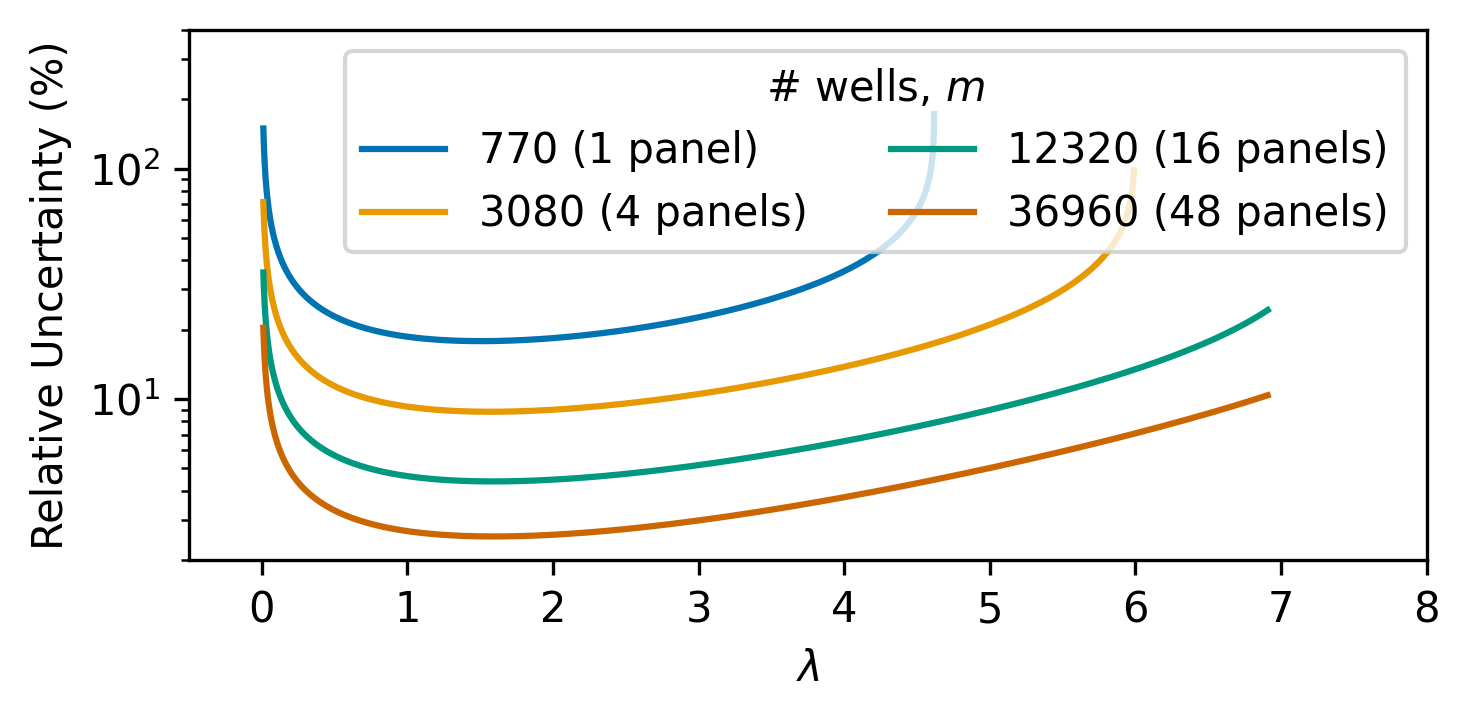

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(5, 2.5), dpi=300)

ns = [770, 4*770, 16*770, 48*770]
for num_wells in ns:
    alpha = 1.96
    ps = np.linspace(0.01, 0.999, num=50000)
    c = (alpha**2)/num_wells
    pmax = ps + c/2 + alpha*np.sqrt((ps*(1-ps)/num_wells) + c/(4*num_wells))/(1 + c)
    pmin = ps + c/2 - alpha*np.sqrt((ps*(1-ps)/num_wells) + c/(4*num_wells))/(1 + c)
    lmax, lmin = -np.log(1-pmax), -np.log(1-pmin)
    lambdas = -np.log(1-ps)
    ax.plot(lambdas, 100*(lmax-lmin)/lambdas, label=f'${int(num_wells)}$')

ax.set_yscale('log')
ax.legend(['{} ({} panels)'.format(i, int(i/770)) if i!=770 else '{} ({} panel)'.format(i, int(i/770)) for i in ns], 
          title='# wells, $m$', ncol=2)
ax.set_ylabel('Relative Uncertainty (%)')
ax.set_xlabel('$\lambda$')
ax.set_ylim((2, 400))
ax.set_xlim((-0.5, 8))

plt.tight_layout()
# plt.savefig('xxx.pdf')
plt.show()

# Plot Probability of Coamplification 

Visualisation of the probability of coamplification for 2 targets as a function of $\lambda$'s

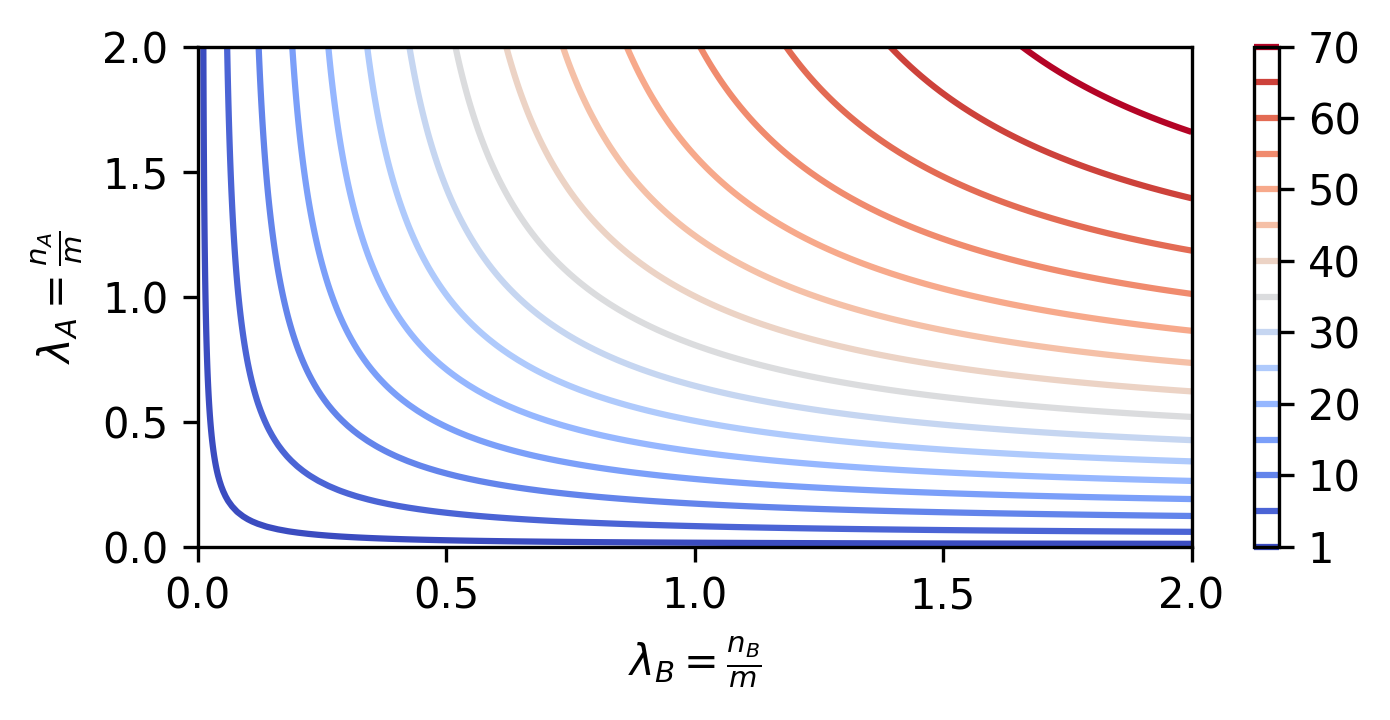

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(5, 2.5), dpi=300)

As = np.linspace(0, 2, 100)
Bs = np.linspace(0, 2, 100)

myfunc = lambda n: (1 - np.exp(-n))

X, Y = np.meshgrid(As, Bs)
Z = np.array([[myfunc(X[i, j]) * myfunc(Y[i, j]) 
               for i in range(X.shape[0])] 
               for j in range(X.shape[1])])
        
errs = np.linspace(0, 0.7, num=15)
errs[0] = 0.01

surf = ax.contour(X, Y, 100*Z, 100*errs, 
                   cmap=cm.coolwarm)


cbar = plt.colorbar(surf, ax=ax)
ax.set_ylabel(r'$\lambda_A = \frac{n_A}{m}$')
ax.set_xlabel(r'$\lambda_B = \frac{n_B}{m}$')
plt.tight_layout()
plt.show()

# Plot Worst-Case % Coamplification 

Visualisation of the worst case % coamplification as a function of $\lambda$ and number of targets.

<>:14: SyntaxWarning: invalid escape sequence '\l'
<>:14: SyntaxWarning: invalid escape sequence '\l'
/var/folders/xt/t6fw9lz91vg0ryq45tpjcjpc0000gn/T/ipykernel_60392/2820491557.py:14: SyntaxWarning: invalid escape sequence '\l'
  ax.legend(Lambdas, title='$\lambda$')


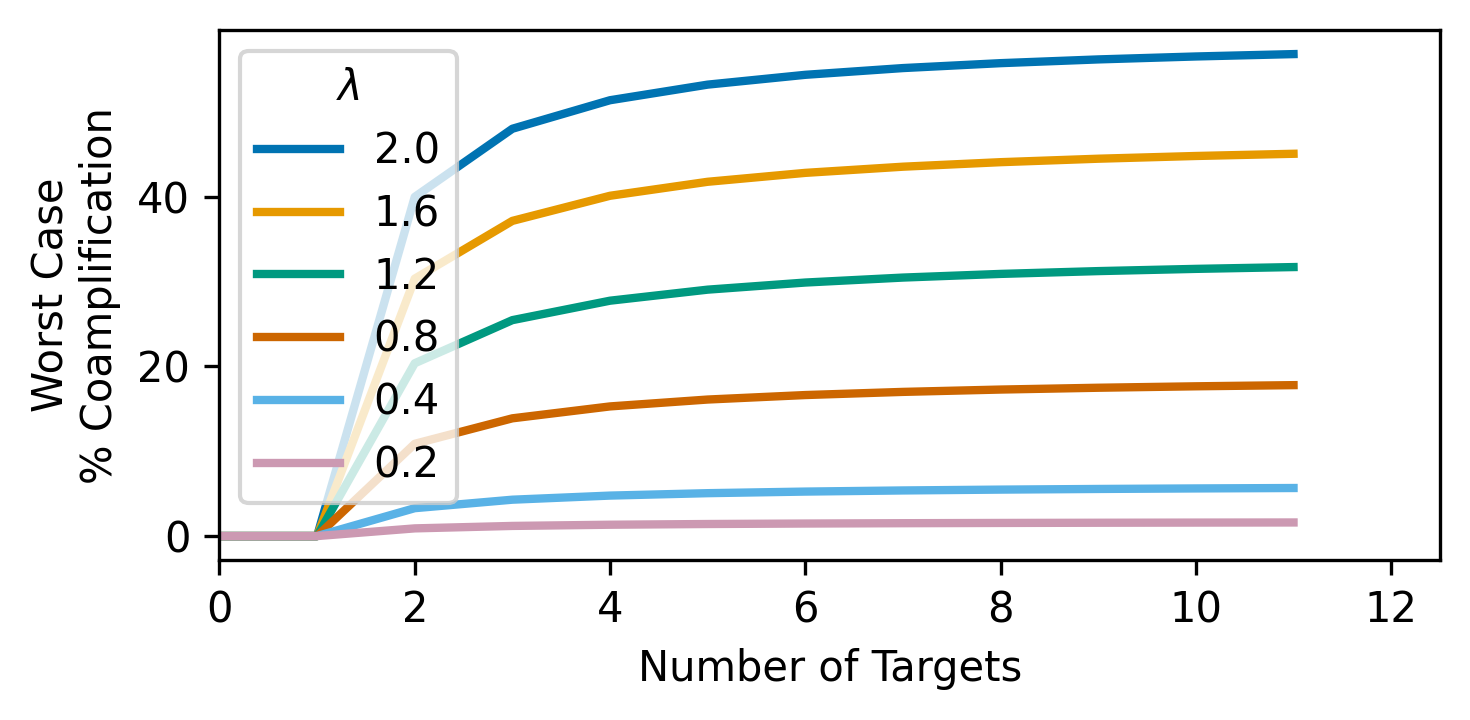

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(5, 2.5), dpi=300)

Ns = np.arange(12)
Lambdas = np.flip(np.array([0.2, 0.4, 0.8, 1.2, 1.6, 2.0]))
Coamps = np.zeros((len(Ns), len(Lambdas)))

for i, l in enumerate(Lambdas):
    Coamps[:, i] = np.array([worst_case_coamps(N=n, l=l) for n in Ns])

ax.plot(Ns, 100*Coamps, linewidth=2)
ax.set_ylabel('Worst Case\n% Coamplification')
ax.set_xlabel('Number of Targets')
ax.set_xlim((0, 12.5))
ax.legend(Lambdas, title='$\lambda$')

plt.tight_layout()
# plt.savefig('xxx.pdf')
plt.show()